# Projet du cours de Machine Learning : analyse du dataset d'OpenFoodFact

# Prediction du nutriscore

## Chargement des données 

### A partir du format csv

In [24]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

In [71]:
INPUT_PATH = "https://static.openfoodfacts.org/data/en.openfoodfacts.org.products.csv.gz"

OUTPUT_PATH = '../data/openfoodfacts_clean.csv'


In [26]:
# Colonnes minimales pour le calcul du Nutri-Score
nutriscore_cols = [
    'energy_100g', 'fat_100g', 'saturated-fat_100g', 
    'sugars_100g', 'fiber_100g', 'proteins_100g', 'carbohydrates_100g',
    'salt_100g'
]

target = ['nutriscore_grade']
identity_cols = ['code', 'product_name']

cols = nutriscore_cols + target + identity_cols

In [ ]:
def process_data(file_path, cols, chunk_size=10000):
    reader = pd.read_csv(
        file_path, compression='gzip', sep='\t',
        on_bad_lines='skip', chunksize=chunk_size,
        low_memory=False, usecols=cols
    )

    clean_chunks = []

    for chunk in reader:
        # 1. On travaille sur une copie du bloc actuel
        temp_chunk = chunk.copy()

        # 2. On élimine d'abord les lignes sans Nutri-Score (Indispensable)
        temp_chunk = temp_chunk.dropna(subset=['nutriscore_grade'])
        temp_chunk = temp_chunk[temp_chunk['nutriscore_grade'].isin(['a', 'b', 'c', 'd', 'e'])]

        # 3. Conversion numérique et remplissage des NaN par 0
        for col in nutriscore_cols:
            temp_chunk[col] = pd.to_numeric(temp_chunk[col], errors='coerce')
        
        temp_chunk[nutriscore_cols] = temp_chunk[nutriscore_cols].fillna(0)

        # 4. Filtres de réalisme (0-100g et Energie)
        for col in nutriscore_cols:
            if col != 'energy_100g':
                temp_chunk = temp_chunk[(temp_chunk[col] >= 0) & (temp_chunk[col] <= 100)]
        
        temp_chunk = temp_chunk[(temp_chunk['energy_100g'] >= 0) & (temp_chunk['energy_100g'] < 4000)]

        # 5. fill the na in product names
        temp_chunk['product_name'] = temp_chunk['product_name'].fillna('Unknown Product')

        # 6 Detection et suppression des doublons
        nb_doublons = temp_chunk.duplicated(subset=['code']).sum()

        if nb_doublons > 0:
            temp_chunk = temp_chunk.drop_duplicates(subset=['code'])


        # 7. AJOUTER le bloc nettoyé à la liste 
        if not temp_chunk.empty:
            clean_chunks.append(temp_chunk)

    return pd.concat(clean_chunks, ignore_index=True)

In [ ]:
df = process_data(INPUT_PATH, cols)


In [63]:
df

,code,product_name,nutriscore_grade,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g
0,7,granola Bio le Chocolaté,c,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
1,8,Unknown Product,c,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
2,9,xytitol pastilles,a,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
3,13,Powdered peanut butter,c,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
4,15,Madeleines ChocoLait,e,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...
1354825,9999999175305,Erdbeerkuchen 1019g tiefgefroren,d,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
1354826,99999995,Steak haché 5%,b,550.5,5.0,2.3,0.0,0.0,0.0,21.5,0.18
1354827,9999999916298,Beurre de cacahuète bio,a,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
1354828,9999999999970,Unknown Product,c,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00


In [ ]:
df.to_csv(OUTPUT_PATH, index=False, encoding="utf-8")
print(f"Fichier sauvegardé : {OUTPUT_PATH}")

Fichier sauvegardé : ../data/openfoodfacts_clean.csv


In [64]:
result = df['nutriscore_grade'].unique()
result

<StringArray>
['c', 'a', 'e', 'd', 'b']
Length: 5, dtype: str

In [65]:
print(df.isna().sum())

code                  0
product_name          0
nutriscore_grade      0
energy_100g           0
fat_100g              0
saturated-fat_100g    0
carbohydrates_100g    0
sugars_100g           0
fiber_100g            0
proteins_100g         0
salt_100g             0
dtype: int64


In [66]:
print(df['nutriscore_grade'].value_counts(normalize=True) * 100)

nutriscore_grade
e    28.068392
d    25.162788
c    20.696693
a    14.468383
b    11.603744
Name: proportion, dtype: float64


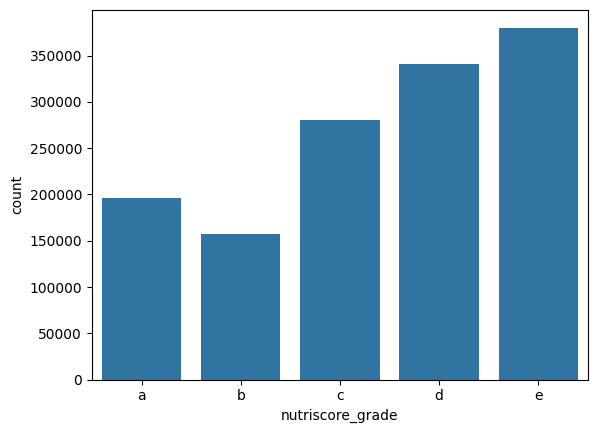

In [73]:
sns.countplot(x='nutriscore_grade', data=df, order=['a', 'b', 'c', 'd', 'e'])
plt.show()

In [74]:
# 2. On "allonge" le DataFrame pour Seaborn
df_melted = df.melt(id_vars=target, 
                    value_vars=nutriscore_cols,
                    var_name='Nutriment', value_name='Valeur (g pour 100g)')

/workspaces/Openfoodfact/.venv/lib/python3.12/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/workspaces/Openfoodfact/.venv/lib/python3.12/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/workspaces/Openfoodfact/.venv/lib/python3.12/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/workspaces/Openfoodfact/.venv/lib/python3.12/site-packages/seaborn/axisgrid.py:854: FutureWar

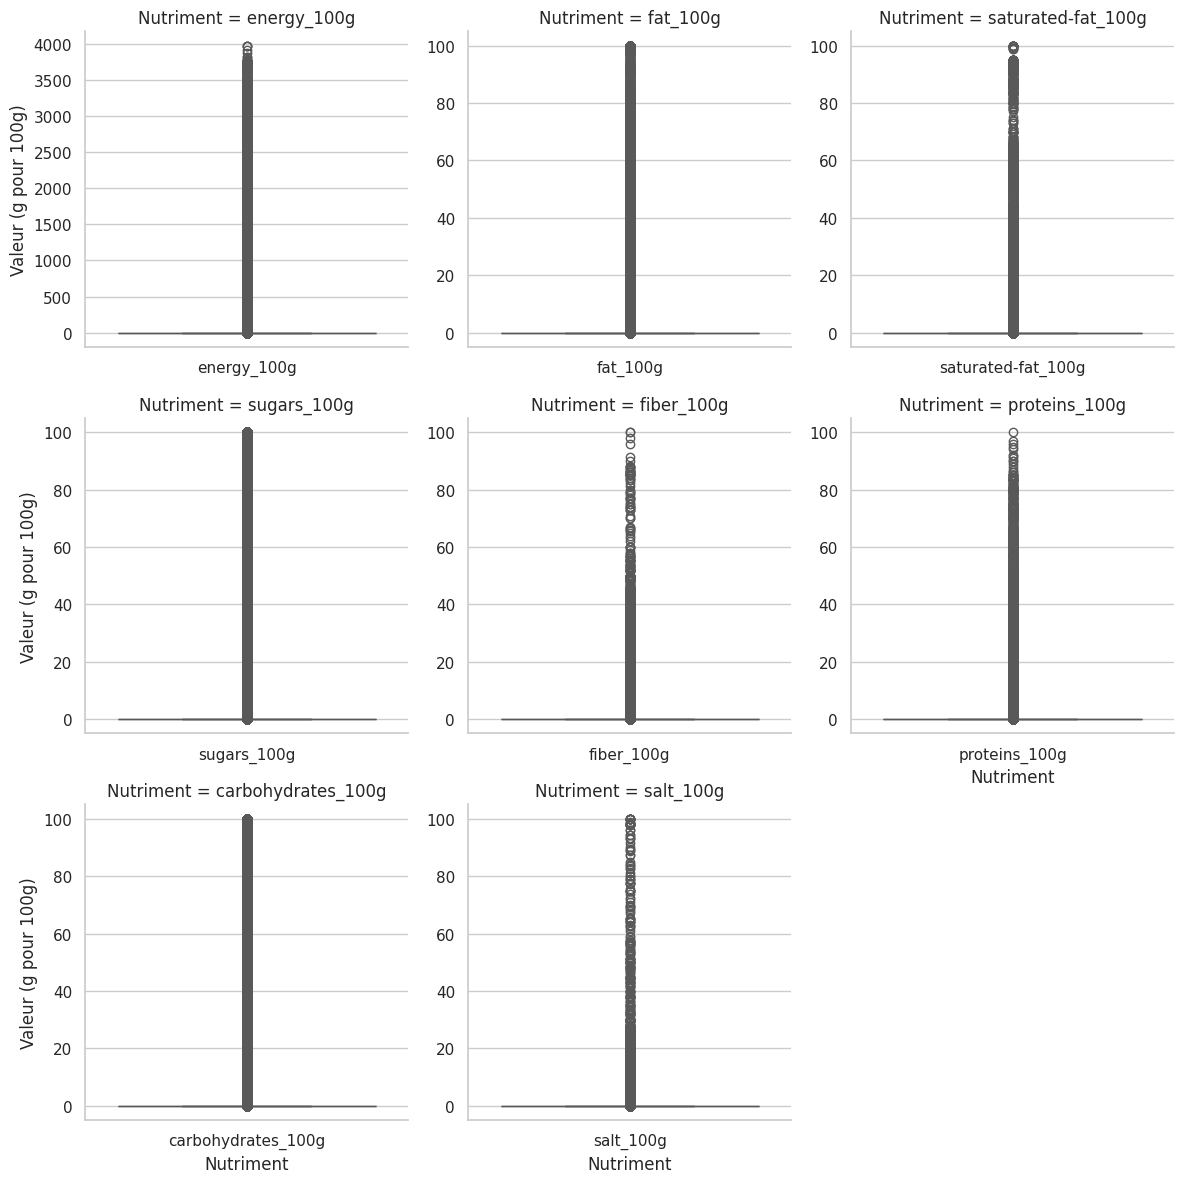

In [75]:
# 3. On crée la visualisation (facettes par nutriment)
sns.set_theme(style="whitegrid")
g = sns.FacetGrid(df_melted, col="Nutriment", col_wrap=3, sharex=False, sharey=False, height=4)
g.map(sns.boxplot, "Nutriment", "Valeur (g pour 100g)", order=None, palette="Set2")

<Axes: xlabel='nutriscore_grade', ylabel='sugars_100g'>

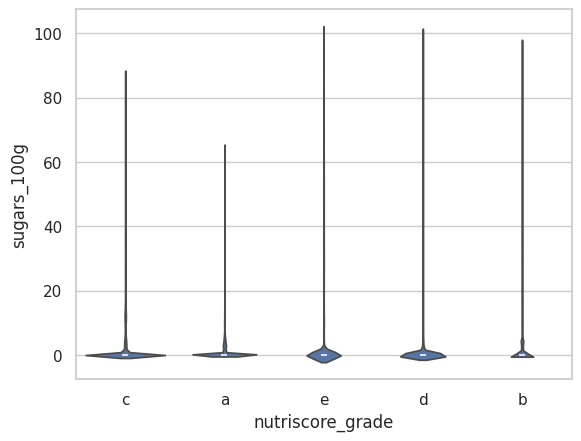

In [77]:
sns.violinplot(x='nutriscore_grade', y='sugars_100g', data=df)

In [4]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 206 columns):
 #    Column                                                 Dtype  
---   ------                                                 -----  
 0    code                                                   int64  
 1    url                                                    object 
 2    creator                                                object 
 3    created_t                                              int64  
 4    created_datetime                                       object 
 5    last_modified_t                                        int64  
 6    last_modified_datetime                                 object 
 7    last_modified_by                                       object 
 8    last_updated_t                                         int64  
 9    last_updated_datetime                                  object 
 10   product_name                                           object

### A partir du format parquet 

parquet est un format optimisé pour la maniupulation de gros data set

on peut charger le data set sous ce format, à partir de [son emplacement sur HuggingFace](https://huggingface.co/datasets/openfoodfacts/product-database) (attention il faudra installer les librairies suivantes pour cela) 

Si ca n'est pas déja fait, télécharger les librairies nécessaires : 
```
pip install huggingface-hub
pip fastparquet

```

In [ ]:
# Login using e.g. `huggingface-cli login` to access this dataset
splits = {'food': 'food.parquet', 'beauty': 'beauty.parquet'}
df = pd.read_parquet("hf://datasets/openfoodfacts/product-database/" + splits["food"])

### Autres méthodes

Pour des détails complets sur les différentes options pour charger les données, consultez la [page dédiée du projet](https://world.openfoodfacts.org/data)